In [1]:
import torch
import random
import numpy as np
import nnsight
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from sympy.combinatorics import CyclicGroup, DihedralGroup, Permutation
from sympy.combinatorics.group_constructs import DirectProduct
from src.tasks.magma import Magma, Quasigroup
from src.load_utils import load_gpt, load_task
from src.intervention_utils import head_output_to_vocab
from src.group_utils import get_pair_with_symbol, get_pair_without_symbol
from src.closure import construct_prompt
from src.data_utils import sample_distribution_sequence

torch.set_grad_enabled(False)

In [2]:
dirname = '../outputs/mixrosette-facts-10-16-8heads'
gpt = load_gpt(dirname).cuda()
task, task_name = load_task(dirname)
model = nnsight.NNsight(gpt)

number of parameters: 50.42M
iteration: inf
Trained on mixrosette up to order 10 with 16 symbols


In [3]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 0.8

### Helper Functions

In [4]:
def decode_sequence(tensor, task):
    """Convert a model output tensor to a string of tokens."""
    return ''.join(task.stringify(tensor.squeeze(0).cpu().numpy()))

def encode_sequence(sequence, task):
    """Convert a token string to a batched input tensor (batch_size=1)."""
    return task.tensor_from_expression(sequence).unsqueeze(0)

In [5]:
def counterfactual_identity_prompt(task, group, num_shots=20, reverse_out=True, base_slot=None):
    """
    Source: identity fact for symbol X in context; query does NOT include X.
    Base:   symbol X in query (not as identity); context has no identity fact for X.
    Counterfactual target: the non-X symbol in the base query.
    """
    order = group.order()
    vocab = task.vocab[:16]
    elems = group.elements
    all_pairs = [(a, b) for a in elems for b in elems]

    while True:
        source_vocab = random.sample(vocab, k=order)
        id_sym = source_vocab[0]

        base_vocab = random.sample([v for v in vocab if v != id_sym], k=order)
        base_vocab[random.randint(1, order - 1)] = id_sym

        source_id_fact, source_wordfor, _ = get_pair_with_symbol(
            group, source_vocab, id_sym, allow_identity_facts=True)
        source_holdout, _, _ = get_pair_without_symbol(
            group, source_vocab, id_sym, allow_identity_facts=False)
        base_holdout, base_wordfor, _ = get_pair_with_symbol(
            group, base_vocab, id_sym, allow_identity_facts=False, slot=base_slot)

        # Source context: includes id_fact; excludes source/base holdouts and source reverse
        src_exclude = {source_holdout, base_holdout}
        if reverse_out:
            src_exclude.add((source_holdout[1], source_holdout[0]))
        src_available = [p for p in all_pairs if p not in src_exclude and p != source_id_fact]
        src_facts = [source_id_fact] + random.choices(src_available, k=num_shots - 2)
        source_prompt = construct_prompt(src_facts, source_holdout, source_wordfor, num_shots)

        # Base context: random facts; excludes base holdout and its reverse
        base_exclude = {base_holdout, (base_holdout[1], base_holdout[0])} if reverse_out else {base_holdout}
        base_facts = random.choices([p for p in all_pairs if p not in base_exclude], k=num_shots - 1)
        base_prompt = construct_prompt(base_facts, base_holdout, base_wordfor, num_shots)

        cf_target = list(set(base_prompt[-4:-2]) - {id_sym}) or [id_sym]

        if base_prompt[-1] != source_prompt[-1]:
            break

    return source_prompt, base_prompt, source_vocab, base_vocab, cf_target


def sample_batch_counterfactual_identity_prompts(task, group, batch_size, num_shots=20, base_slot=None):
    """Batch version of counterfactual_identity_prompt. Returns source/base tensors and counterfactual targets."""
    s1, s2, v1, v2, ct = zip(*[counterfactual_identity_prompt(task, group, num_shots=num_shots, base_slot=base_slot)
                                for _ in range(batch_size)])
    s1 = task.tensor_from_expression(s1)
    s2 = task.tensor_from_expression(s2)
    return {'source_prompts': s1[:, :-1], 'source_targets': s1[:, -1],
            'base_prompts':   s2[:, :-1], 'base_targets':   s2[:, -1],
            'source_vocab': v1, 'base_vocab': v2,
            'counterfactual_targets': task.tensor_from_expression(ct).squeeze().long()}


def sample_identity_prompt(task, group, num_shots=20, reverse_out=True, slot=None):
    """
    Sample a single sequence where the query is an identity fact (e*x=x or x*e=x).

    Args:
        slot: 'a' (identity in left slot), 'b' (right slot), or None (either).
    Returns:
        (prompt_str, vocab_list)
    """
    source_vocab = random.sample(task.vocab[:16], k=group.order())
    id_fact, wordfor, _ = get_pair_with_symbol(
        group, source_vocab, source_vocab[0], allow_identity_facts=True, slot=slot)

    elems = group.elements
    available = [(a, b) for a in elems for b in elems if (a, b) != id_fact]
    if reverse_out:
        available = [p for p in available if p != (id_fact[1], id_fact[0])]

    return construct_prompt(random.choices(available, k=num_shots - 1), id_fact, wordfor, num_shots), source_vocab


def sample_batch_identity_prompts(task, group, batch_size, num_shots=20, slot=None):
    """Batch version of sample_identity_prompt. Returns source prompt tensors and vocab."""
    s, v = zip(*[sample_identity_prompt(task, group, num_shots=num_shots, slot=slot)
                 for _ in range(batch_size)])
    s = task.tensor_from_expression(s)
    return {'source_prompts': s[:, :-1], 'source_targets': s[:, -1], 'source_vocab': v}

### Figure 5a: PCA of Identity Embeddings

Collect Layer 3 attention activations at the predictive token for identity vs.
non-identity queries. Identity and non-identity facts separate cleanly along PC1.

In [6]:
# Set MULTI_GROUP = True to collect across all training groups,
# False to use CyclicGroup(8) only (matches Rohit's original notebook).
MULTI_GROUP = True

n_components = 32
pos_idx      = -1
n_shot_pca   = 100
n_layers = model.config.n_layer

if MULTI_GROUP:
    groups_pca  = ([CyclicGroup(o) for o in [4, 5, 6, 7, 8, 9, 10]] +
                   [DihedralGroup(n) for n in [3, 4, 5]])
    N_per_group = 150   # ~1050 total
else:
    groups_pca  = [CyclicGroup(8)]
    N_per_group = 1000

identity_vecs    = {L: [] for L in range(n_layers)}
nonidentity_vecs = {L: [] for L in range(n_layers)}

for group in tqdm(groups_pca, desc='groups'):
    order = group.order()
    for _ in tqdm(range(N_per_group), desc=f'{group.__class__.__name__}({order})', leave=False):
        id_prompt, _ = sample_identity_prompt(task, group, num_shots=n_shot_pca)
        identity_inputs = encode_sequence(id_prompt, task)[:, :-1]

        non_id_seq, _, _, _ = sample_distribution_sequence(task, n_shot_pca, 'other', fixed_groups=[group])
        non_identity_inputs = encode_sequence(non_id_seq, task)[:, :-1]

        with model.trace(identity_inputs):
            for L in range(n_layers):
                identity_vecs[L].append(
                    model.transformer.h[L].attn.output[0, pos_idx, :].cpu().save())

        with model.trace(non_identity_inputs):
            for L in range(n_layers):
                nonidentity_vecs[L].append(
                    model.transformer.h[L].attn.output[0, pos_idx, :].cpu().save())

groups:   0%|          | 0/10 [00:00<?, ?it/s]

PermutationGroup(4):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(5):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(6):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(7):   0%|          | 0/150 [00:00<?, ?it/s]

...

PermutationGroup(9):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(10):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(6):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(8):   0%|          | 0/150 [00:00<?, ?it/s]

PermutationGroup(10):   0%|          | 0/150 [00:00<?, ?it/s]

In [7]:
layer_pca = {}

for L in range(n_layers):
    X_id  = torch.stack(identity_vecs[L], dim=0)      # [N, D]
    X_non = torch.stack(nonidentity_vecs[L], dim=0)   # [N, D]

    X = torch.cat([X_id, X_non], dim=0)               # [2N, D]
    Xc = X - X.mean(0, keepdim=True)

    q = min(n_components, X.shape[1])
    U, S, V = torch.pca_lowrank(Xc, q=q)
    components = V[:, :q].T.contiguous()               # [q, D]
    explained_variance = (S[:q] ** 2) / (X.shape[0] - 1)

    layer_pca[L] = {'components': components,
                    'explained_variance': explained_variance,
                    'X_id': X_id, 'X_non': X_non}

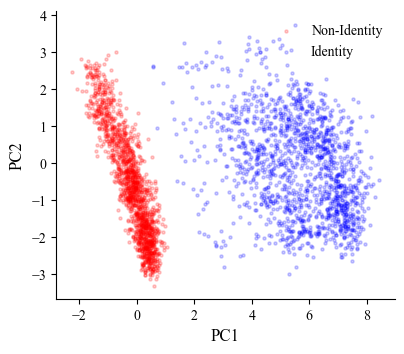

In [8]:
# Figure 5a: 2D PCA scatter at Layer 3 attention
X_id  = layer_pca[3]['X_id']
X_non = layer_pca[3]['X_non']
comp  = layer_pca[3]['components']

proj_id  = (X_id  @ comp[:2].T).numpy()
proj_non = (X_non @ comp[:2].T).numpy()

fig, ax = plt.subplots(1, 1, figsize=(4, 3.5))
ax.scatter(proj_non[:, 0], proj_non[:, 1], color='red',  alpha=0.2, s=5, label='Non-Identity')
ax.scatter(proj_id[:, 0],  proj_id[:, 1],  color='blue', alpha=0.2, s=5, label='Identity')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='best', frameon=False)
plt.tight_layout(pad=0.5)
# plt.savefig('identity_pca.pdf', bbox_inches='tight', dpi=300)
plt.show()

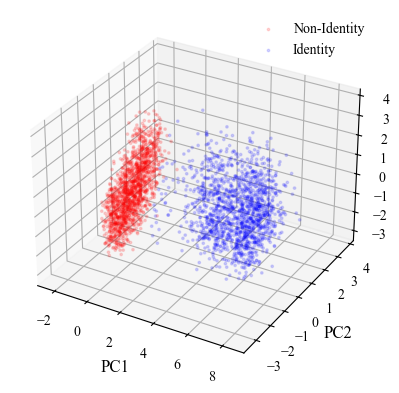

In [9]:
# 3D PCA scatter at Layer 3 attention
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X_id  = layer_pca[3]['X_id']
X_non = layer_pca[3]['X_non']
comp  = layer_pca[3]['components']

proj_id  = (X_id  @ comp[:3].T).numpy()
proj_non = (X_non @ comp[:3].T).numpy()

fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(proj_non[:, 0], proj_non[:, 1], proj_non[:, 2],
           color='red',  alpha=0.15, s=3, label='Non-Identity')
ax.scatter(proj_id[:, 0],  proj_id[:, 1],  proj_id[:, 2],
           color='blue', alpha=0.15, s=3, label='Identity')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Figure 5b: Head 3.1 Identity Matching

For each (layer, head), use the logit lens to measure how well that head's output
predicts the identity query answer. Head 3.1 stands out.

In [10]:
groups_heads  = (
    [CyclicGroup(o) for o in [4, 6, 8, 10]] +
    [DihedralGroup(n) for n in [3, 4, 5]]
)
num_shots     = 50
batch_per_grp = 30   # 7 groups × 30 = 210 total

raw_batches = [sample_batch_identity_prompts(task, g, batch_per_grp, num_shots)
               for g in groups_heads]
source_prompts = torch.cat([b['source_prompts'] for b in raw_batches], dim=0)
source_targets = torch.cat([b['source_targets'] for b in raw_batches], dim=0)

identity_matching_scores = torch.zeros((model.config.n_layer, model.config.n_head))

for L in range(model.config.n_layer):
    for H in range(model.config.n_head):
        logits = head_output_to_vocab(model, source_prompts, (L, H)).detach().cpu()[:, :16]
        identity_matching_scores[L, H] = (logits.argmax(-1) == source_targets).float().mean()
        torch.cuda.empty_cache()

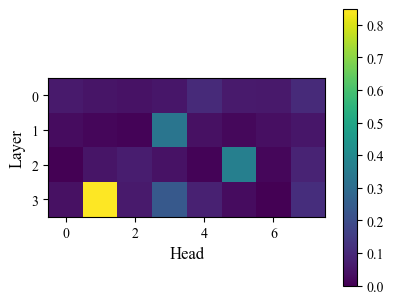

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
im = ax.imshow(identity_matching_scores)
plt.colorbar(im, ax=ax)
ax.set_xlabel('Head')
ax.set_ylabel('Layer')
plt.tight_layout(pad=0.5)
# plt.savefig('identity_head_scores.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Head 3.1 Left/Right Query Promotion Across Groups

Head 3.1 should promote the non-identity element (right slot when `e*a=?`, left slot when `a*e=?`).
We measure this across all group types in the training distribution.


C2 slot=left:   0%|          | 0/50 [00:00<?, ?it/s]

C2 slot=right:   0%|          | 0/50 [00:00<?, ?it/s]

C3 slot=left:   0%|          | 0/50 [00:00<?, ?it/s]

C3 slot=right:   0%|          | 0/50 [00:00<?, ?it/s]

C4 slot=left:   0%|          | 0/50 [00:00<?, ?it/s]

...

D3 slot=right:   0%|          | 0/50 [00:00<?, ?it/s]

D4 slot=left:   0%|          | 0/50 [00:00<?, ?it/s]

D4 slot=right:   0%|          | 0/50 [00:00<?, ?it/s]

D5 slot=left:   0%|          | 0/50 [00:00<?, ?it/s]

D5 slot=right:   0%|          | 0/50 [00:00<?, ?it/s]

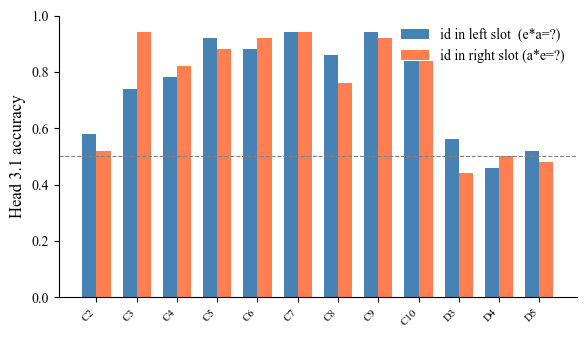

Mean left-slot:  75.17%
Mean right-slot: 74.67%


In [12]:
from sympy.combinatorics import CyclicGroup, DihedralGroup

# DihedralGroup(n) has order 2n; cap at n=5 (order 10) to stay in-distribution.
all_groups = []
for order in range(2, 11):
    all_groups.append((f'C{order}', CyclicGroup(order)))
for n in range(3, 6):
    all_groups.append((f'D{n}', DihedralGroup(n)))

n_test_per_group = 50
L_focus, H_focus = 3, 1  # head 3.1

group_results = {}
for name, group in all_groups:
    cnt_left, cnt_right = 0, 0

    for slot, label in [('a', 'left'), ('b', 'right')]:
        cnt = 0
        for _ in tqdm(range(n_test_per_group), desc=f'{name} slot={label}', leave=False):
            try:
                id_batch = sample_batch_identity_prompts(task, group, batch_size=1,
                                                         num_shots=200, slot=slot)
                target_tok = task.stringify([id_batch['source_targets'][0].item()])[0]
                logits = head_output_to_vocab(model, id_batch['source_prompts'],
                                              (L_focus, H_focus)).squeeze().detach().cpu()
                if task.stringify([logits.argmax().item()])[0] == target_tok:
                    cnt += 1
                torch.cuda.empty_cache()
            except Exception:
                pass

        if slot == 'a':
            cnt_left = cnt
        else:
            cnt_right = cnt

    group_results[name] = (cnt_left / n_test_per_group, cnt_right / n_test_per_group)

names = list(group_results.keys())
left_rates  = [group_results[n][0] for n in names]
right_rates = [group_results[n][1] for n in names]

x = np.arange(len(names))
w = 0.35
fig, ax = plt.subplots(figsize=(max(6, len(names)*0.4), 3.5))
ax.bar(x - w/2, left_rates,  w, label='id in left slot  (e*a=?)', color='steelblue')
ax.bar(x + w/2, right_rates, w, label='id in right slot (a*e=?)', color='coral')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Head 3.1 accuracy')
ax.set_ylim(0, 1)
ax.axhline(0.5, ls='--', color='gray', lw=0.8)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Mean left-slot:  {np.mean(left_rates):.2%}")
print(f"Mean right-slot: {np.mean(right_rates):.2%}")

### Figure 5c: QP Steering

Steering along the first PCA component of the identity subspace at Layer 3 attention
causes the model to treat the query as if it involves an identity element.

Three conditions (single qualitative example, then quantitative test over 10k samples):
1. QP steering only
2. QP steering + fake left identity fact prepended (predicts right query variable)
2. QP steering + fake right identity fact prepended (predicts left query variable)
4. Steering away from identity on identity sequences

In [13]:
# Single qualitative example
group_to_test = CyclicGroup(8)
l3_component  = layer_pca[3]['components']

non_id_seq, _, _, _ = sample_distribution_sequence(task, 100, 'other', fixed_groups=[group_to_test], unshuffled=True)
non_identity_inputs   = encode_sequence(non_id_seq, task)[:, :-1]
non_identity_sequence = non_id_seq[:-1]   # strip answer; ends with '='
left_variable  = non_identity_sequence[-3]
right_variable = non_identity_sequence[-2]

# Baseline
with model.trace(non_identity_inputs):
    base_out = model.output.save()
print(f"Baseline:  {non_identity_sequence} -> {decode_sequence(base_out[0].argmax(2).cpu(), task)[-1:]}")

# QP Steering
with model.trace(non_identity_inputs):
    model.transformer.h[3].attn.output[:, pos_idx] += 5 * l3_component[0].to(model.device)
    base_out = model.output.save()
print(f"QP Steer:  {non_identity_sequence} -> {decode_sequence(base_out[0].argmax(2).cpu(), task)[-1:]}")

# QP Steering + fake identity fact for left variable (expects right_variable)
seq_fake_id = f',8{left_variable}=8' + non_identity_sequence
with model.trace(encode_sequence(seq_fake_id, task)):
    model.transformer.h[3].attn.output[:, pos_idx] += 5 * l3_component[0].to(model.device)
    base_out = model.output.save()
pred = decode_sequence(base_out[0].argmax(2).cpu(), task)[-1:]
print(f"QP + fake id (left_variable): {seq_fake_id} -> {pred}  (expected: {right_variable})")

Baseline:  ,00=0,25=7,67=5,61=7,56=3,46=2,55=2,06=6,36=1,12=3,06=6,45=1,31=4,03=3,34=7,22=4,66=4,45=1,52=7,03=3,35=0,67=5,25=7,11=2,23=5,63=1,44=0,72=1,66=4,64=2,50=5,02=2,02=2,66=4,07=7,15=6,24=6,32=5,72=1,57=4,46=2,67=5,11=2,24=6,70=7,00=0,57=4,24=6,00=0,22=4,23=5,16=7,71=0,00=0,24=6,25=7,67=5,22=4,36=1,21=3,11=2,22=4,64=2,62=0,66=4,72=1,15=6,11=2,44=0,34=7,24=6,52=7,30=3,57=4,10=1,65=3,02=2,43=7,74=3,13=4,05=5,50=5,71=0,13=4,20=2,11=2,16=7,13=4,31=4,74=3,50=5,77=6,24=6,10=1,37=2,56=3,15=6,21=3,11=2,41= -> 5
QP Steer:  ,00=0,25=7,67=5,61=7,56=3,46=2,55=2,06=6,36=1,12=3,06=6,45=1,31=4,03=3,34=7,22=4,66=4,45=1,52=7,03=3,35=0,67=5,25=7,11=2,23=5,63=1,44=0,72=1,66=4,64=2,50=5,02=2,02=2,66=4,07=7,15=6,24=6,32=5,72=1,57=4,46=2,67=5,11=2,24=6,70=7,00=0,57=4,24=6,00=0,22=4,23=5,16=7,71=0,00=0,24=6,25=7,67=5,22=4,36=1,21=3,11=2,22=4,64=2,62=0,66=4,72=1,15=6,11=2,44=0,34=7,24=6,52=7,30=3,57=4,10=1,65=3,02=2,43=7,74=3,13=4,05=5,50=5,71=0,13=4,20=2,11=2,16=7,13=4,31=4,74=3,50=5,77=6,24=6,10=1,37

PermutationGroup(4):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(5):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(6):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(7):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(8):   0%|          | 0/50 [00:00<?, ?it/s]

...

PermutationGroup(10):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(6):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(8):   0%|          | 0/50 [00:00<?, ?it/s]

PermutationGroup(10):   0%|          | 0/50 [00:00<?, ?it/s]

Cond 1 — steer only (left):   70.6%, (right): 29.0%
Cond 2 — QP + demote left  → right:   78.2%
Cond 3 — QP + demote right → left:    97.8%
Cond 4 — false id + steer away:        86.2%


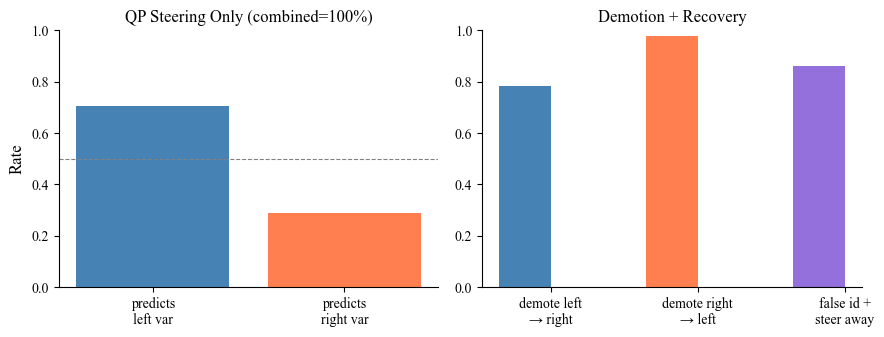

In [14]:
# Quantitative steering experiments (Appendix E) over multiple groups.
#
# Cond 1: QP steering only (+5v1) — measures % predicting either query variable (~99.2% combined)
#         Bar chart shows left vs. right split (expected ~50% each = symmetric query promotion)
# Cond 2: QP + false LEFT-slot id  (left_var*foreign=foreign → left_var acts as identity)
#         Head 3.6 suppresses left_var → model predicts right_var 
# Cond 3: QP + false RIGHT-slot id (foreign*right_var=foreign → right_var acts as identity)
#         Head 3.6 suppresses right_var → model predicts left_var 
# Cond 4: Inject false id + steer AWAY (-5v1) → model recovers correct answer
#
# Foreign symbol: task.vocab[order] is guaranteed outside the group's vocab (task.vocab[:order]).

from sympy.combinatorics import CyclicGroup, DihedralGroup

test_groups = []
for order in range(4, 11):
    test_groups.append(CyclicGroup(order))
for n in range(3, 6):   # D3(6), D4(8), D5(10)
    test_groups.append(DihedralGroup(n))

n_per_group   = 50
steer_alpha   = 5
pos_idx_steer = -1
l3_comp = layer_pca[3]['components']

cond1_left, cond1_right = [], []
cond2_all, cond3_all, cond4_all = [], [], []

for group in test_groups:
    order = group.order()
    foreign = task.vocab[order]

    cnt1_left = cnt1_right = cnt2 = cnt3 = cnt4 = 0

    for _ in tqdm(range(n_per_group), desc=f'{group.__class__.__name__}({order})', leave=False):
        try:
            seq_non_full, _, _, _ = sample_distribution_sequence(task, 100, 'other', fixed_groups=[group])
            seq_non   = seq_non_full[:-1]   # strip answer; ends with '='
            inputs_non = encode_sequence(seq_non_full, task)[:, :-1]
            target    = seq_non_full[-1]
            left_var  = seq_non[-3]
            right_var = seq_non[-2]

            # Cond 1: QP steering only
            with model.trace(inputs_non):
                model.transformer.h[3].attn.output[:, pos_idx_steer] += steer_alpha * l3_comp[0].to(model.device)
                out1 = model.output.save()
            pred1 = decode_sequence(out1[0].argmax(2).cpu(), task)[-1:]
            if pred1 == left_var:
                cnt1_left += 1
            elif pred1 == right_var:
                cnt1_right += 1

            # Cond 2: QP + false LEFT-slot id (left_var*foreign=foreign → left_var acts as identity)
            seq_fake_left = f',{left_var}{foreign}={foreign}' + seq_non
            with model.trace(encode_sequence(seq_fake_left, task)):
                model.transformer.h[3].attn.output[:, pos_idx_steer] += steer_alpha * l3_comp[0].to(model.device)
                out2 = model.output.save()
            if decode_sequence(out2[0].argmax(2).cpu(), task)[-1:] == right_var:
                cnt2 += 1

            # Cond 3: QP + false RIGHT-slot id (foreign*right_var=foreign → right_var acts as identity)
            seq_fake_right = f',{foreign}{right_var}={foreign}' + seq_non
            with model.trace(encode_sequence(seq_fake_right, task)):
                model.transformer.h[3].attn.output[:, pos_idx_steer] += steer_alpha * l3_comp[0].to(model.device)
                out3 = model.output.save()
            if decode_sequence(out3[0].argmax(2).cpu(), task)[-1:] == left_var:
                cnt3 += 1

            # Cond 4 (Appendix): inject false LEFT-slot id + steer AWAY → recover correct answer
            with model.trace(encode_sequence(seq_fake_left, task)):
                model.transformer.h[3].attn.output[:, pos_idx_steer] -= steer_alpha * l3_comp[0].to(model.device)
                out4 = model.output.save()
            if decode_sequence(out4[0].argmax(2).cpu(), task)[-1:] == target:
                cnt4 += 1
        except Exception:
            pass

    cond1_left.append(cnt1_left / n_per_group)
    cond1_right.append(cnt1_right / n_per_group)
    cond2_all.append(cnt2 / n_per_group)
    cond3_all.append(cnt3 / n_per_group)
    cond4_all.append(cnt4 / n_per_group)

c1_combined = np.mean(cond1_left) + np.mean(cond1_right)
print(f"Cond 1 — steer only (left):   {np.mean(cond1_left):.1%}, (right): {np.mean(cond1_right):.1%}")
print(f"Cond 2 — QP + demote left  → right:   {np.mean(cond2_all):.1%}")
print(f"Cond 3 — QP + demote right → left:    {np.mean(cond3_all):.1%}")
print(f"Cond 4 — false id + steer away:        {np.mean(cond4_all):.1%}")

# Summary plots
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Left: cond 1 — left/right split under pure QP steering
axes[0].bar(['predicts\nleft var', 'predicts\nright var'],
            [np.mean(cond1_left), np.mean(cond1_right)],
            color=['steelblue', 'coral'])
axes[0].axhline(0.5, ls='--', color='gray', lw=0.8)
axes[0].set_title(f'QP Steering Only (combined={c1_combined:.0%})')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0, 1)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: conds 2, 3, 4
labels = ['demote left\n→ right', 'demote right\n→ left', 'false id +\nsteer away']
values = [np.mean(cond2_all), np.mean(cond3_all), np.mean(cond4_all)]
x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, values, w, label='measured', color=['steelblue', 'coral', 'mediumpurple'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)
axes[1].set_title('Demotion + Recovery')
# axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Causal Patching: Head Indirect Effects

Measures the average indirect effect of each (layer, head) on the counterfactual
identity prediction using source/base prompt pairs.

In [15]:
groups_causal  = (
    [CyclicGroup(o) for o in [4, 6, 8, 10]] +
    [DihedralGroup(n) for n in [3, 4, 5]]
)
causal_per_grp = 30   # 7 groups × 30 = 210 total

raw_cf = [sample_batch_counterfactual_identity_prompts(task, g, causal_per_grp, num_shots=50)
          for g in groups_causal]
cf_batch = {
    'source_prompts':        torch.cat([b['source_prompts']        for b in raw_cf], dim=0),
    'base_prompts':          torch.cat([b['base_prompts']          for b in raw_cf], dim=0),
    'counterfactual_targets': torch.cat([b['counterfactual_targets'] for b in raw_cf], dim=0),
}
cf_batch_size = cf_batch['source_prompts'].shape[0]

scores = torch.zeros(cf_batch_size, model.config.n_layer, model.config.n_head)

with torch.no_grad():
    for layer_index in range(model.config.n_layer):
        for head_index in range(model.config.n_head):
            module = model.transformer.h[layer_index].attn.c_proj

            with model.trace(cf_batch['source_prompts']):
                attn_in = module.input
                x_src = attn_in.reshape(cf_batch_size, -1, model.config.n_head,
                                         model.config.n_embd // model.config.n_head).save()

            with model.trace(cf_batch['base_prompts']):
                clean_out = model.lm_head.output[:, -1].save()

            with model.trace(cf_batch['base_prompts']):
                attn_in = module.input
                x_base = attn_in.reshape(cf_batch_size, -1, model.config.n_head,
                                          model.config.n_embd // model.config.n_head)
                x_base[:, -1, head_index, :] = x_src[:, -1, head_index, :]
                interv_out = model.lm_head.output[:, -1].save()

            score = interv_out - clean_out
            scores[:, layer_index, head_index] = score.gather(
                1, cf_batch['counterfactual_targets'].cuda().unsqueeze(1)).squeeze()

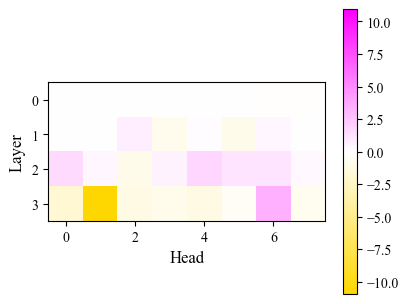

In [16]:
data = scores.mean(0)
cmap = LinearSegmentedColormap.from_list('spring_white', ['gold', 'white', 'magenta'], N=256)
norm = TwoSlopeNorm(vmin=data.min(), vcenter=0, vmax=-data.min())

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
im = ax.imshow(data, cmap=cmap, norm=norm)
plt.colorbar(im, ax=ax)
ax.set_xlabel('Head')
ax.set_ylabel('Layer')
plt.tight_layout(pad=0.5)
# plt.savefig('identity_causal_patching.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Head 3.1 and Head 3.6 Individual Token Logits

For a single identity query, visualize what each head promotes via the logit lens.
Head 3.1 should promote the non-identity operand; head 3.6 (copying) promotes the left operand.


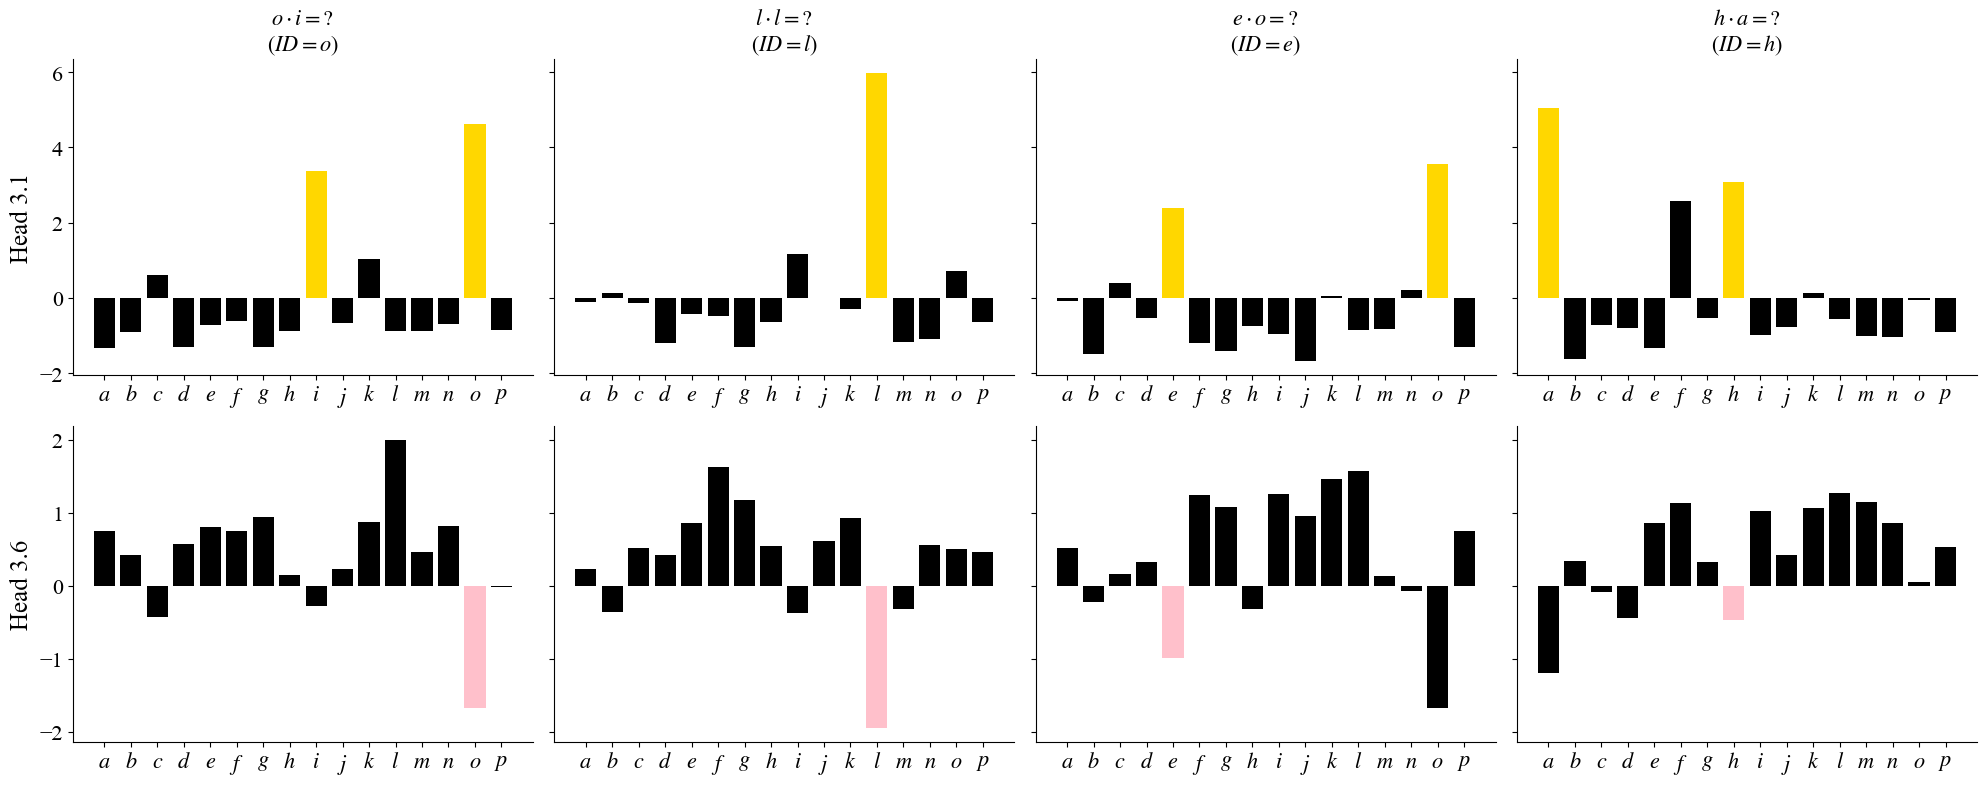

In [23]:
# Figure 5b style: black bars, gold = query tokens (head 3.1), pink = identity token (head 3.6)
# 2 rows (heads 3.1, 3.6) x 4 columns (4 different identity prompts)
n_prompts = 4
group_plot = CyclicGroup(8)
heads = [(3, 1), (3, 6)]
LETTERS = 'abcdefghijklmnop'

prompts_plot = []
for _ in range(n_prompts):
    b = sample_batch_identity_prompts(task, group_plot, batch_size=1, num_shots=50, slot='a')
    prompts_plot.append((b['source_prompts'], list(b['source_vocab'][0])))

fig, axes = plt.subplots(len(heads), n_prompts,
                         figsize=(5 * n_prompts, 4 * len(heads)), sharey='row')

for col_idx, (inputs_p, vocab_p) in enumerate(prompts_plot):
    # identity is left query operand (slot='a'), non-identity is right
    id_tok    = inputs_p[0, -3].item()   # token index of identity in query
    non_id_tok = inputs_p[0, -2].item()  # token index of non-identity in query
    id_letter  = LETTERS[id_tok]
    nid_letter = LETTERS[non_id_tok]

    for row_idx, head in enumerate(heads):
        ax = axes[row_idx, col_idx]

        full_logits = head_output_to_vocab(model, inputs_p, head, token_idx=-1)
        logits = full_logits[0, :16].detach().cpu()

        ax.bar(range(16), logits, color='black')

        if row_idx == 0:  # head 3.1: highlight both query operands in gold
            ax.bar([id_tok, non_id_tok], logits[[id_tok, non_id_tok]], color='gold')
        else:             # head 3.6: highlight only the identity operand in pink
            ax.bar(id_tok, logits[id_tok], color='pink')

        ax.set_xticks(range(16))
        ax.set_xticklabels([rf'${x}$' for x in LETTERS], fontsize=16)
        ax.tick_params(axis='y', labelsize=16)

        if col_idx == 0:
            ax.set_ylabel(f'Head {head[0]}.{head[1]}', fontsize=18)
        if row_idx == 0:
            ax.set_title(rf'${id_letter} \cdot {nid_letter}=?$' + '\n' + rf'($ID={id_letter}$)', fontsize=16)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('identity_head_logits.pdf', bbox_inches='tight', dpi=300)
plt.show()


In [18]:
# torch.save({
#     'layer_pca':                layer_pca,
#     'identity_matching_scores': identity_matching_scores,
#     'causal_patching_scores':   scores,
# }, '../outputs/identity_mechanism_results.pt')

In [19]:
# # Load previously saved results
# results = torch.load('../outputs/identity_mechanism_results.pt')
# layer_pca                = results['layer_pca']
# identity_matching_scores = results['identity_matching_scores']
# causal_patching_scores   = results['causal_patching_scores']